Step 1 : Sentimental Analysis

In [36]:
import numpy as np  #for uploading the data
import pandas as pd  #for mathematical task
import re #for regular expression, data cleaning
import nltk
import matplotlib.pyplot as plt   #visualization
from nltk.corpus import stopwords #data cleaning  corpus- collection of all the document
from nltk.tokenize import word_tokenize   #
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

#Download required NLTK files
nltk.download('punkt')  #punctuation
nltk.download('stopwords')  #
nltk.download('vader_lexicon')  #(valence aware dictionnary and sentence reasoner) rule based statement analysis
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Step 2

In [37]:
# Generate random dataset of 100 comments

data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)


df.head()

,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged.
2,Customer service was helpful and responsive.
3,The delivery was delayed and support team did ...
4,Amazing product. Worth the money.


Step 3

In [38]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = word_tokenize(text.lower())
    words = [word for word in words if word not in stop_words]
    cleaned_text=" ".join(words) # Join words with spaces
    return cleaned_text

df['Cleaned_Review'] = df['Review'].apply(clean_text)
df.head
print('\ncleaned review')
print(df[['Review','Cleaned_Review']])


cleaned review
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             Cleaned_Review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4               amazing product worth money  
5  poor quality product terrible experience  
6              fast shipping good packaging  

Step 4: Sentimental Analysis

In [39]:
sia =SentimentIntensityAnalyzer()

def analyze_sentiment(review):

  score = sia.polarity_scores(review)

  compound = score['compound']

  if compound >= 0.05:
    return 'Positive'

  elif compound <= -0.05:
    return 'Negative'

  else:
    return 'Neutral'

df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

print("\nSentiment Analysis Results")
print(df[['Review','Sentiment']])


Sentiment Analysis Results
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [40]:
all_words = ' '.join([text for text in df['Cleaned_Review']])

word_list = all_words.split()
#Count word frequency
word_freq = Counter(word_list)
#Display top 10 keywords
print("\n Top 10 Common Keyword")
print(word_freq.most_common(10))


 Top 10 Common Keyword
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [41]:
negative_reviews = df[df['Sentiment'] == 'Negative']   #Row filtering based on other value
negative_words = " ".join(negative_reviews['Cleaned_Review'])
negative_words_list = negative_words.split()
complaint_freq = Counter(negative_words_list)
print("\n Most Common Complaint keywords")
print(complaint_freq.most_common(10))


 Most Common Complaint keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


Step 7: Visualization: Sentiment Count

In [42]:
snetiment_counts = df['Sentiment'].value_counts()
print("\n Sentiment Distribution")
print(snetiment_counts)


 Sentiment Distribution
Sentiment
Positive    6
Negative    4
Name: count, dtype: int64


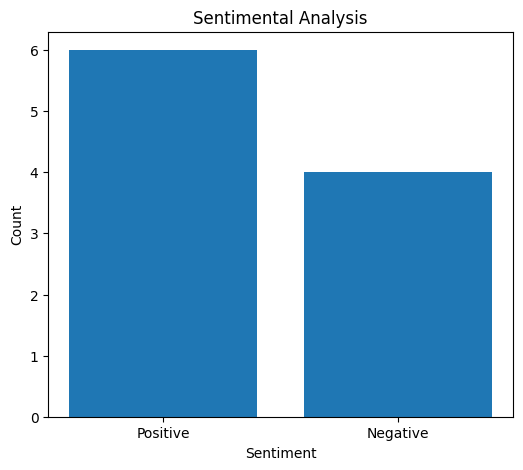

In [43]:
sentiment_counts = df['Sentiment'].value_counts() #it wil give category count

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentimental Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

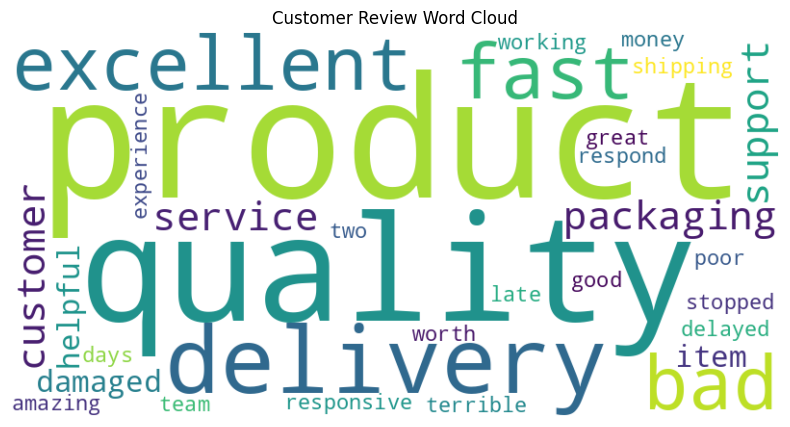

In [44]:
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = 'white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Customer Review Word Cloud")
plt.show()

In [45]:
print("\nBusiness Insights")
print("------------------------------")

positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])

print("Total Positive Reviews :", positive_count)
print("Total Negative Reviews :", negative_count)

print("\nCommon Positive Areas:")
print("- Product quality")
print("- Fast delivery")
print("- Good customer service")

print("\nCommon Customer Complaints:")
print("- Delayed delivery")
print("- Damaged products")


print()


Business Insights
------------------------------
Total Positive Reviews : 6
Total Negative Reviews : 4

Common Positive Areas:
- Product quality
- Fast delivery
- Good customer service

Common Customer Complaints:
- Delayed delivery
- Damaged products

